# Arbeitsblatt 1

In [2]:
#Imports der benötigten Pakete
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#Einlesen der CSV-Datei
data = pd.read_csv('DABI2_Projekt1.csv')
data


,Unnamed: 0,rate,DateTime,KWH,meters
0,0,Std,2011-11-23 09:00:00.0000000,0.355,1
1,1,Std,2011-11-23 09:30:00.0000000,0.414,1
2,2,Std,2011-11-23 10:00:00.0000000,0.698,4
3,3,Std,2011-11-23 10:30:00.0000000,0.455,4
4,4,Std,2011-11-23 11:00:00.0000000,0.670,5
...,...,...,...,...,...
80685,80685,ToU,2014-02-27 22:00:00.0000000,302.767,1026
80686,80686,ToU,2014-02-27 22:30:00.0000000,286.752,1026
80687,80687,ToU,2014-02-27 23:00:00.0000000,254.521,1026
80688,80688,ToU,2014-02-27 23:30:00.0000000,211.434,1026


In [3]:
# Erster Blick auf die Daten
data.head()
#Daten bereinigen und in das richtige Format bringen
data['DateTime'] = pd.to_datetime(data['DateTime'], format='mixed')


# Aufgabe 1: 
Prüfen Sie den Energieverbrauch auf Trends und Periodizität, trennen Sie die verschiedenen Bestandteile und visualisieren Sie sie geeigneter Weise.

(array([15340., 15431., 15522., 15614., 15706., 15796., 15887., 15979.,
        16071., 16161.]),
 [Text(15340.0, 0, '2012-01'),
  Text(15431.0, 0, '2012-04'),
  Text(15522.0, 0, '2012-07'),
  Text(15614.0, 0, '2012-10'),
  Text(15706.0, 0, '2013-01'),
  Text(15796.0, 0, '2013-04'),
  Text(15887.0, 0, '2013-07'),
  Text(15979.0, 0, '2013-10'),
  Text(16071.0, 0, '2014-01'),
  Text(16161.0, 0, '2014-04')])

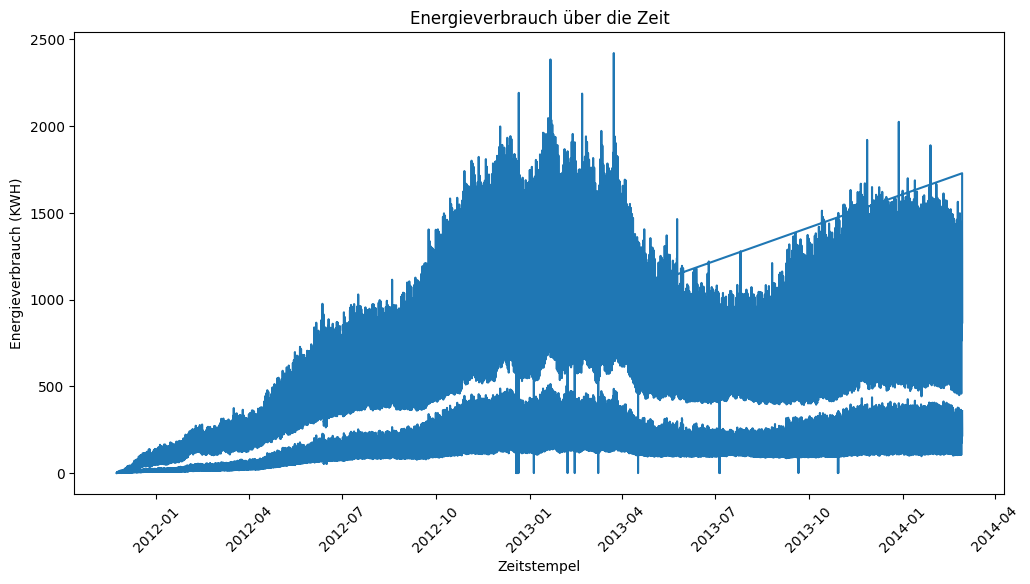

In [ ]:
#Visualisierung des Energieverbrauchs über die Zeit
plt.figure(figsize=(12, 6))
plt.plot(data["DateTime"], data["KWH"])
plt.xlabel("Zeitstempel")
plt.ylabel("Energieverbrauch (KWH)")
plt.title("Energieverbrauch über die Zeit")
plt.xticks(rotation=45)

In [37]:
#Zeitstempel als Index setzen
data.reset_index(inplace=True)
data.set_index('DateTime', inplace=True)

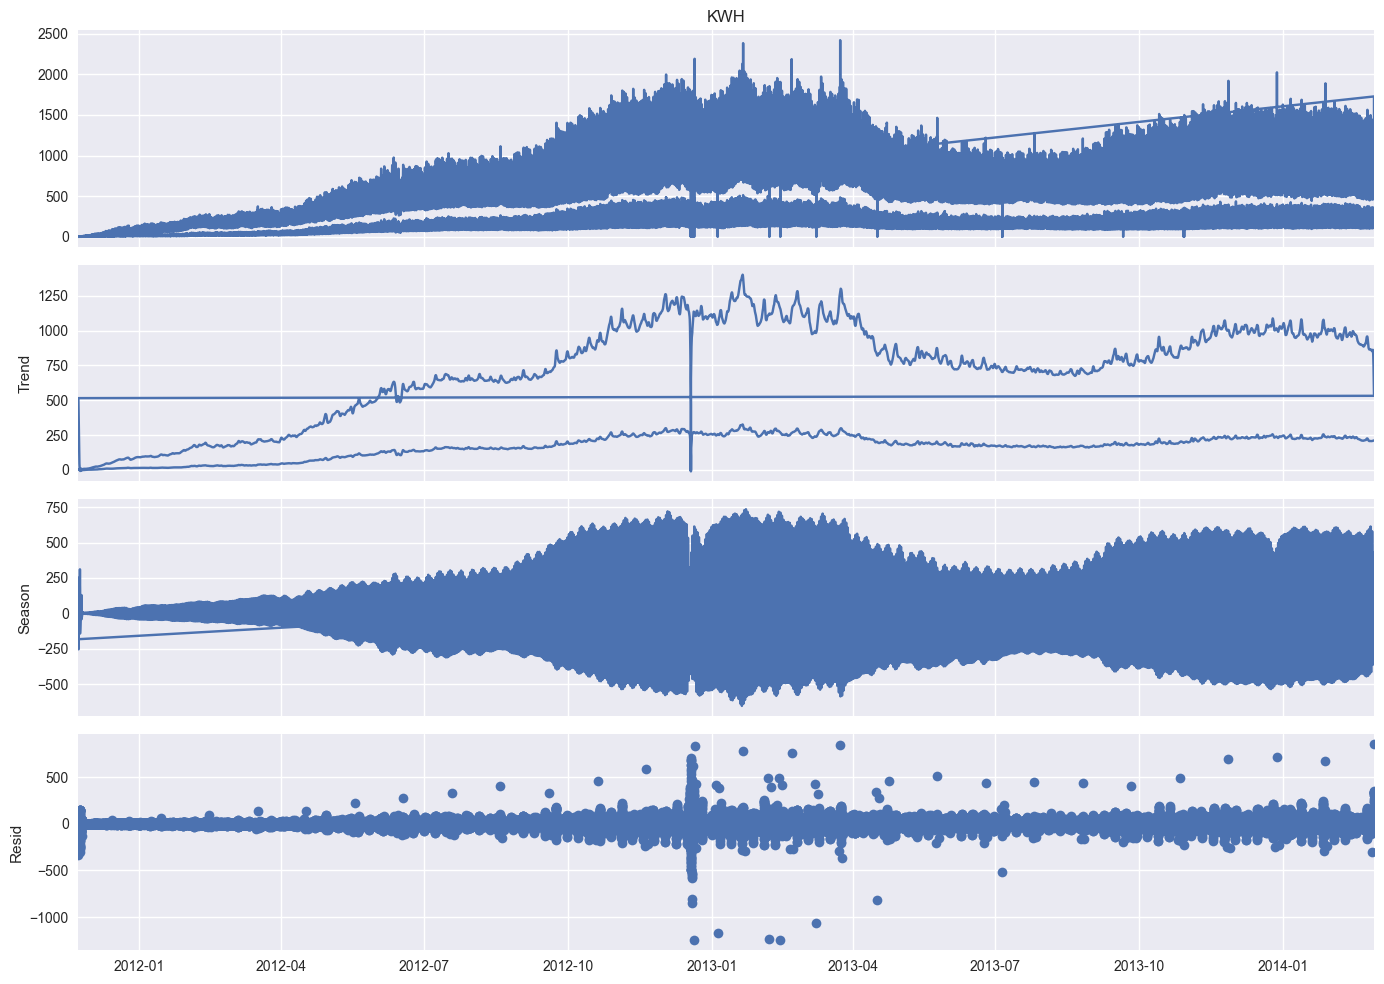

In [32]:
#STL- Zerlegung durchführen um periodische Muster und Trends zu identifizieren
from statsmodels.tsa.seasonal import STL
stl= STL(data["KWH"],period=48) #period=48 für halbstündliche Muster
result = stl.fit()

result.trend
result.seasonal
result.resid

#Visualisierung der Bestandteile
plt.style.use("seaborn-v0_8")
plt.rcParams.update({'font.size': 12})

fig = result.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

# Aufgabe 2
Ermitteln Sie die Autokorrelationen und partiellen Autokorrelationen der Zeitreihe.

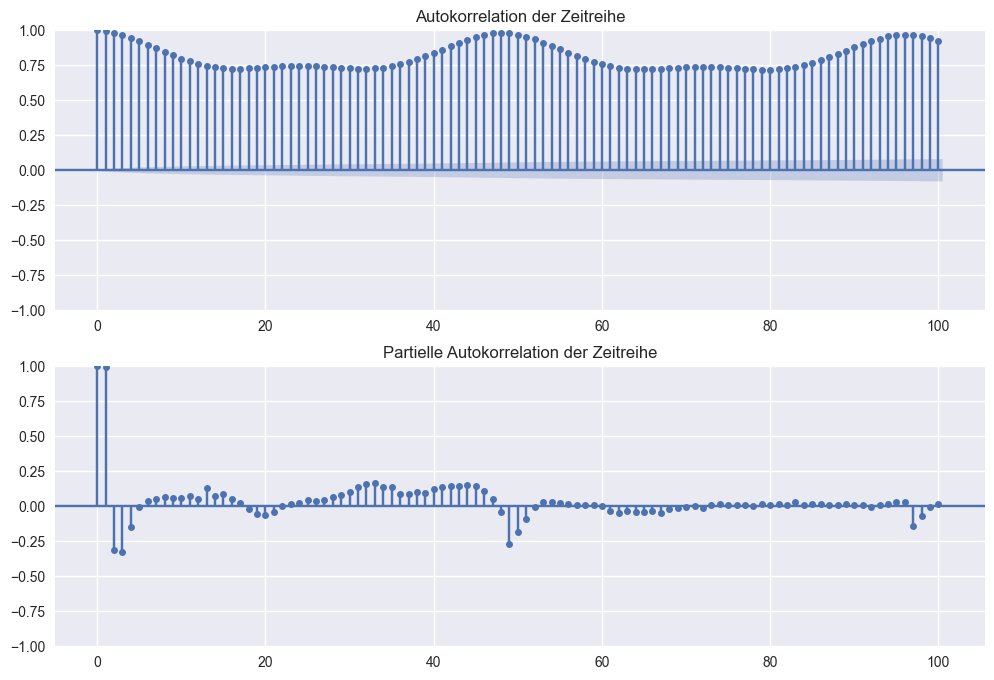

In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(data["KWH"], lags=100, ax=axes[0])
axes[0].set_title("Autokorrelation der Zeitreihe")

plot_pacf(data["KWH"], lags=100, ax=axes[1])
axes[1].set_title("Partielle Autokorrelation der Zeitreihe")

plt.show()



# Aufgabe 3
### Interpretation der Korrelationen
Die Analyse der Autokorrelationsfunktion zeigt, dass die Zeitreihe über viele Lags hinweg hohe Korrelationswerte aufweist. Dies bedeutet, dass aktuelle Werte stark von vergangenen Werten abhängen und somit eine deutliche zeitliche Struktur vorhanden ist. Zudem ist in der Autokorrelation eine klare periodische Wellenform erkennbar, was auf wiederkehrende Muster in der Zeitreihe hinweist.

Die partielle Autokorrelationsfunktion zeigt ebenfalls signifikante Ausschläge bei mehreren Lags, was darauf hindeutet, dass direkte Abhängigkeiten zwischen den Beobachtungen bestehen. Insbesondere die Kombination aus langsam abklingender Autokorrelation und strukturierten Peaks spricht dafür, dass sowohl Trend als auch saisonale Effekte in der Zeitreihe vorhanden sind.

Insgesamt lässt sich feststellen, dass die Zeitreihe nicht stationär ist und noch ausgeprägte Muster enthält, die durch die bisherige Zerlegung nicht vollständig entfernt wurden. Die vorhandenen Autokorrelationen und periodischen Strukturen zeigen, dass wichtige Zusammenhänge in den Daten bestehen, die bei der Modellierung berücksichtigt werden müssen.

### Verbesserungsmöglichkeiten zum Lösen der Probleme
Um die bestehenden Probleme zu beheben, sollten weitere Modellanpassungen vorgenommen werden. Eine Möglichkeit besteht darin, mehrere saisonale Komponenten zu berücksichtigen, da Energieverbrauchsdaten häufig sowohl tägliche als auch wöchentliche Muster aufweisen. Beispielsweise könnte zusätzlich zur täglichen Periodizität auch eine wöchentliche Periodizität in die Analyse einbezogen werden.

Darüber hinaus kann eine Differenzierung der Zeitreihe helfen, um den Trend zu entfernen und die Stationarität zu verbessern. Auch der Einsatz geeigneter Zeitreihenmodelle wie SARIMA bietet sich an, da diese sowohl Trend als auch saisonale Effekte modellieren können.

Eine weitere Verbesserung besteht darin, zusätzliche erklärende Variablen zu berücksichtigen, wie etwa Wochentage, Uhrzeiten oder externe Einflussfaktoren. Insgesamt sollte das Modell erweitert werden, sodass die verbleibenden Autokorrelationen reduziert werden und die Zeitreihe besser beschrieben werden kann.